In [39]:
import numpy as np
import matplotlib.pyplot as plt

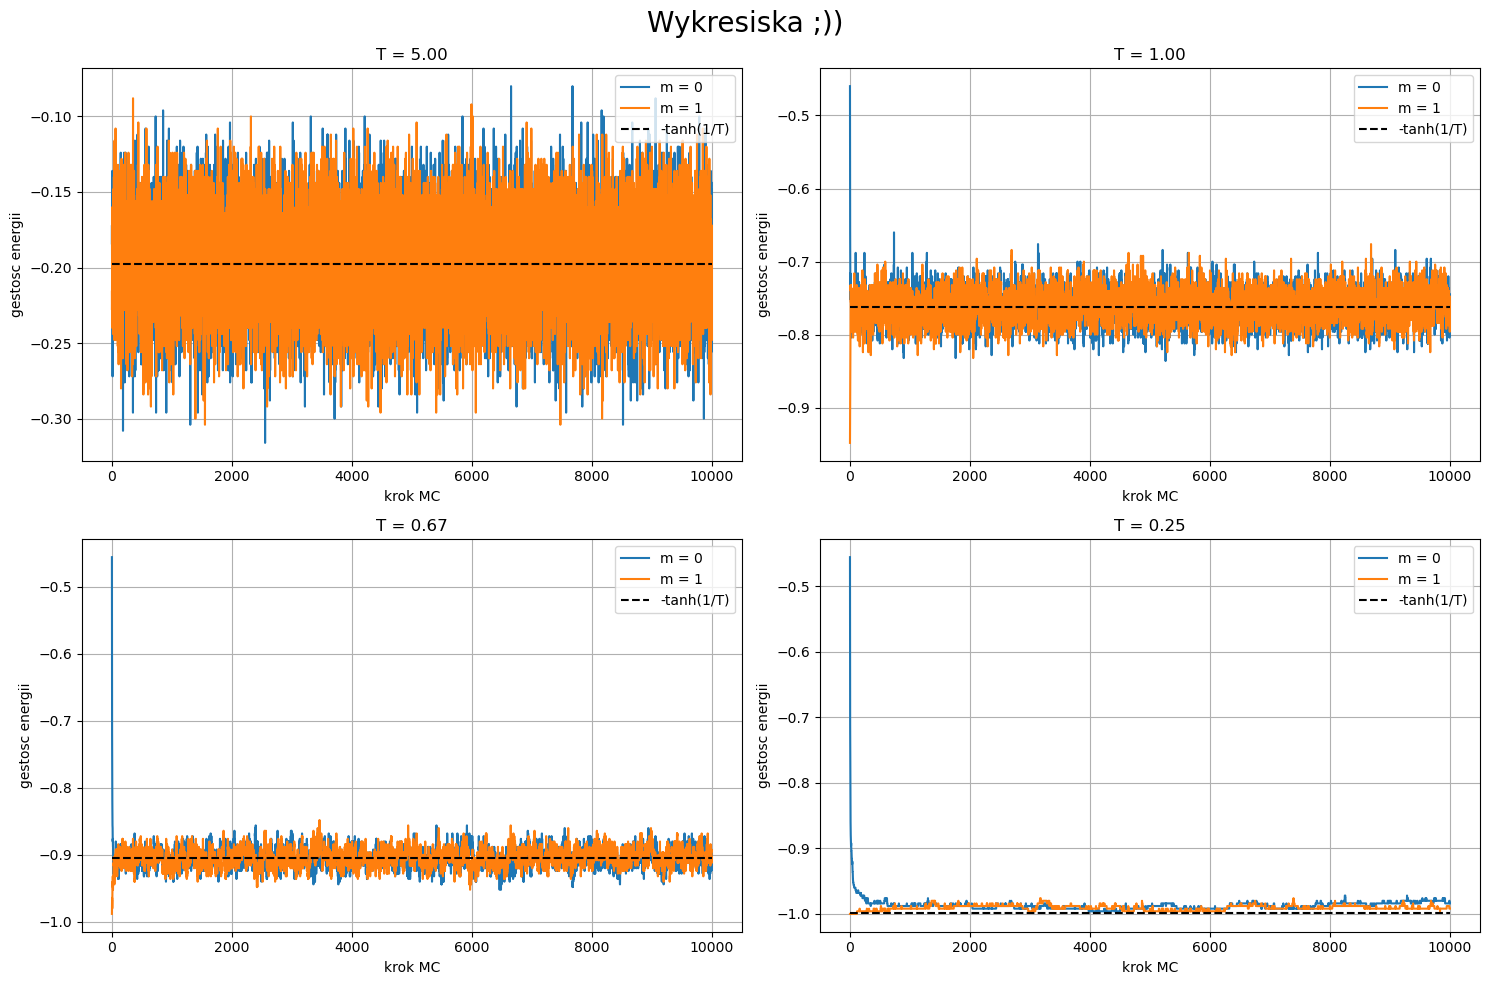

In [38]:
data = np.loadtxt('energie.dat')
titles = ['T = 5; m = 0', 'T = 1; m = 0', 'T = 0.25; m = 0', 'T = 0.33; m = 0',
        'T = 5; m = 1', 'T = 1; m = 1', 'T = 0.25; m = 1', 'T = 0.33; m = 1']
T = [5, 1, 2/3, 0.25]
data = data.tolist()

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Wykresiska ;))", fontsize=20)

for i, t in enumerate(T):
    row, col = divmod(i, 2)
    axs[row, col].plot(data[i], label=f'm = 0')
    axs[row, col].plot(data[i + 4], label=f'm = 1')
    axs[row, col].plot(np.linspace(0, len(data[0])), 
                    np.ones_like(np.linspace(0, len(data[0])))*(-np.tanh(1/t)), 
                    label=f'-tanh(1/T)', linestyle = '--', color = 'k')
    axs[row, col].set_title(f'T = {t:.2f}')
    axs[row, col].set_xlabel('krok MC')
    axs[row, col].set_ylabel('gestosc energii')
    axs[row, col].legend()
    #axs[row, col].set_xscale('log')
    axs[row, col].grid(True)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

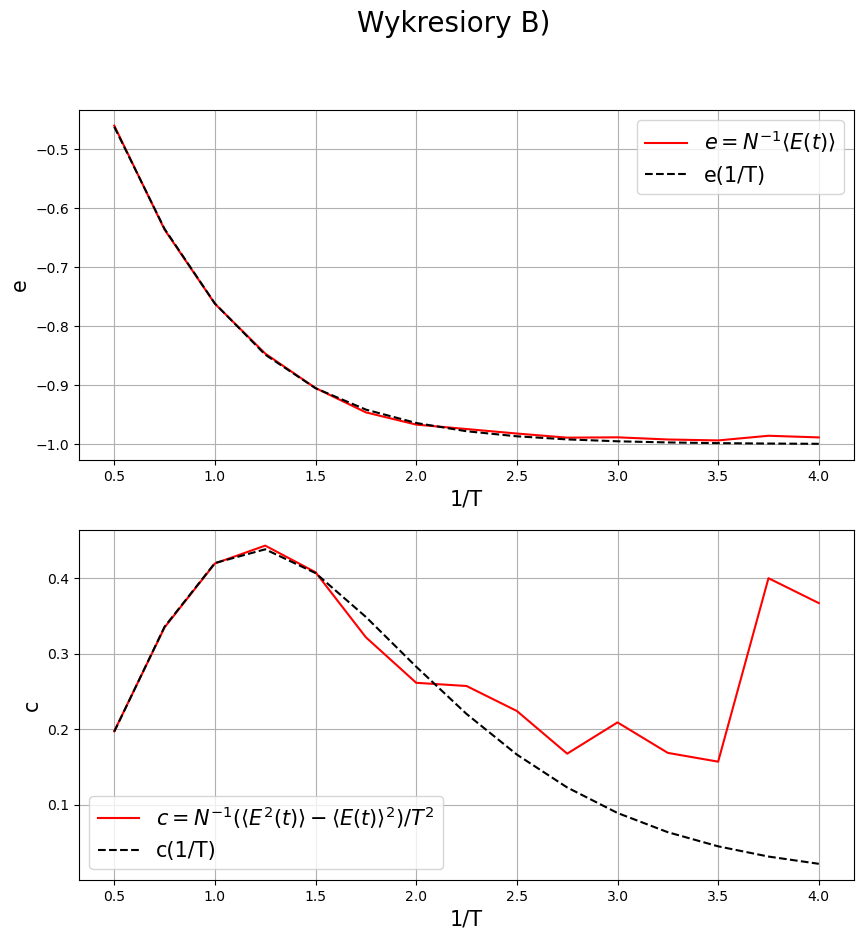

In [37]:
data = np.loadtxt('vals.dat')
data = data.T

fig, axs = plt.subplots(2, 1, figsize=(10, 10))
fig.suptitle("Wykresiory B)", fontsize=20)

axs[0].plot(data[0], data[1],
            label = r'$e = N^{-1}⟨E(t)⟩$', color = 'r')
axs[0].plot(data[0], list(map(lambda T_inv: -np.tanh(T_inv), data[0])),
            label = 'e(1/T)', linestyle = '--', color = 'k')

axs[1].plot(data[0], (data[2] - data[1]**2)*data[0]**2,
            label = r'$c = N^{-1}(⟨E^2(t)⟩-⟨E(t)⟩^2)/T^2$', color = 'r')
axs[1].plot(data[0], list(map(lambda T_inv: (T_inv**2)/(np.cosh(T_inv)**2), data[0])),
            label = 'c(1/T)', linestyle = '--', color = 'k')

axs[0].set_ylabel('e', fontsize=15)
axs[0].set_xlabel('1/T', fontsize=15)

axs[1].set_ylabel('c', fontsize=15)
axs[1].set_xlabel('1/T', fontsize=15)

axs[0].legend(fontsize = 15)
axs[1].legend(fontsize = 15)

axs[0].grid(True)
axs[1].grid(True)

plt.show()